In [2]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [5]:
with open("../data/experiment_data.json") as f:
    data = json.load(f)

df = pd.DataFrame(data)

df.head()

,participant_id,trial_number,condition,decision,latency_ms,ai_correct,confidence_score,timestamp,manipulation_check
0,P_a2wvu4lg,1.0,humanlike,accept,2476.0,False,3.0,2026-03-09T05:54:14.455Z,NaN
1,P_a2wvu4lg,2.0,humanlike,override,1245.0,True,5.0,2026-03-09T05:54:18.521Z,NaN
2,P_a2wvu4lg,3.0,humanlike,accept,1480.0,False,2.0,2026-03-09T05:54:22.739Z,NaN
3,P_a2wvu4lg,4.0,humanlike,override,1363.0,True,5.0,2026-03-09T05:54:26.205Z,NaN
4,P_a2wvu4lg,5.0,humanlike,accept,1446.0,False,5.0,2026-03-09T05:54:30.071Z,NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   participant_id      6 non-null      object 
 1   trial_number        5 non-null      float64
 2   condition           5 non-null      object 
 3   decision            5 non-null      object 
 4   latency_ms          5 non-null      float64
 5   ai_correct          5 non-null      object 
 6   confidence_score    5 non-null      float64
 7   timestamp           5 non-null      object 
 8   manipulation_check  1 non-null      object 
dtypes: float64(3), object(6)
memory usage: 564.0+ bytes


In [7]:
accept_rate = (df["decision"] == "accept").mean()

print("Overall acceptance rate:", accept_rate)

Overall acceptance rate: 0.5


In [8]:
df.groupby("condition")["decision"].apply(
    lambda x: (x == "accept").mean()
)

condition
humanlike    0.6
Name: decision, dtype: float64

In [9]:
df.groupby("condition")["latency_ms"].mean()

condition
humanlike    1602.0
Name: latency_ms, dtype: float64

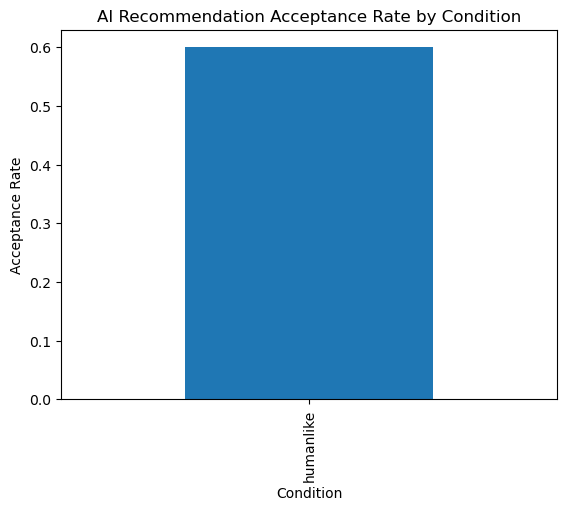

In [10]:
trust_by_condition = df.groupby("condition")["decision"].apply(
    lambda x: (x == "accept").mean()
)

trust_by_condition.plot(kind="bar")

plt.title("AI Recommendation Acceptance Rate by Condition")
plt.ylabel("Acceptance Rate")
plt.xlabel("Condition")

plt.show()

In [11]:
df.groupby(["condition","ai_correct"])["decision"].apply(
    lambda x: (x == "accept").mean()
)

condition  ai_correct
humanlike  False         1.0
           True          0.0
Name: decision, dtype: float64